In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

In [18]:
breast_cancer_df = load_breast_cancer()
X, y = breast_cancer_df.data, breast_cancer_df.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
rng = np.random.default_rng(42)
w = rng.standard_normal(30) * 0.01
b = rng.standard_normal() * 0.01

In [20]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [21]:
def forward(x, w, b):
    z = np.dot(x, w) + b
    return sigmoid(z)

In [22]:
first_five_test = X_test_scaled[:5]
probabilities = [forward(row, w, b) for row in first_five_test]

In [23]:
for i, prob in enumerate(probabilities):
    print(f"Row {i+1}: {prob:.4f}")

Row 1: 0.5002
Row 2: 0.5206
Row 3: 0.5019
Row 4: 0.4937
Row 5: 0.4979


In [24]:
class NumpyMLP:
    def __init__(self, input_dim=30, hidden_dim=8, output_dim=1):
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros((1, hidden_dim))

        self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2.0 / hidden_dim)
        self.b2 = np.zeros((1, output_dim))

    def relu(self, z):
        return np.maximum(0, z)

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.relu(self.z1)

        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)

        return self.a2

In [25]:
mlp = NumpyMLP()
predictions = mlp.forward(X_test_scaled)
print(predictions[:5])

[[0.45299955]
 [0.46601069]
 [0.56604814]
 [0.40817775]
 [0.36364703]]


The output shape is a direct consequence of the architectural design (the hardcoded matrix dimensions), not the values within the weights; by setting the final weight matrix to have a column dimension of **1**, we ensure that every input vector is mathematically transformed into a single scalar value, which the **Sigmoid** function then maps to the $[0, 1]$ probability range required for binary classification.

In [32]:
class TorchMLP(nn.Module):
    def __init__(self):
        super(TorchMLP, self).__init__()
        # Architecture: 30 -> 8 -> 1
        self.fc1 = nn.Linear(30, 8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        z1 = self.fc1(x)        # Pre-activation
        a1 = self.relu(z1)      # Post-activation
        output = self.sigmoid(self.fc2(a1))
        return z1, a1, output   # <--- Return all 3 values

In [34]:
torchMLP = TorchMLP()
with torch.no_grad():
    torchMLP.fc1.weight.copy_(torch.from_numpy(mlp.W1.T).float())
    torchMLP.fc1.bias.copy_(torch.from_numpy(mlp.b1.flatten()).float())
    torchMLP.fc2.weight.copy_(torch.from_numpy(mlp.W2.T).float())
    torchMLP.fc2.bias.copy_(torch.from_numpy(mlp.b2.flatten()).float())

X_test_tensor = torch.from_numpy(X_test_scaled).float()

with torch.no_grad():
    # Unpack the 3 values, keeping only the third (final output)
    _, _, pytorch_predictions = torchMLP(X_test_tensor)

    # Convert to numpy for comparison
    pytorch_predictions_np = pytorch_predictions.numpy()

print(pytorch_predictions_np[:5])

[[0.45299956]
 [0.46601075]
 [0.56604815]
 [0.40817776]
 [0.363647  ]]


In [36]:
max_diff = np.max(np.abs(predictions - pytorch_predictions_np))
max_diff

np.float64(1.0537967731760745e-07)

In [40]:
class TorchSigmoidMLP(nn.Module):
    def __init__(self):
        super(TorchSigmoidMLP, self).__init__()
        self.fc1 = nn.Linear(30,8)
        self.sigmoid = nn.Sigmoid()
        self.fc2 = nn.Linear(8,1)

    def forward(self, x):
        z1 = self.fc1(x)        # Pre-activation
        a1 = self.sigmoid(z1)      # Post-activation
        output = self.sigmoid(self.fc2(a1))
        return z1, a1, output   # <--- Return all 3 values

In [41]:
class TorchTanhMLP(nn.Module):
    def __init__(self):
        super(TorchTanhMLP, self).__init__()
        self.fc1 = nn.Linear(30,8)
        self.tanh = nn.Tanh()
        self.fc2 = nn.Linear(8,1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        z1 = self.fc1(x)        # Pre-activation
        a1 = self.tanh(z1)      # Post-activation
        output = self.sigmoid(self.fc2(a1))
        return z1, a1, output   # <--- Return all 3 values

In [42]:
test_batch = torch.tensor(X_test_scaled, dtype=torch.float32)

models = {
    "Sigmoid": TorchSigmoidMLP(),
    "Tanh": TorchTanhMLP(),
    "ReLU": TorchMLP()
}

pre_acts = {}
post_acts = {}

for name, model in models.items():
    model.eval() # Set to evaluation mode
    with torch.no_grad():
        z1, a1, _ = model(test_batch)
        pre_acts[name] = z1.numpy().flatten()
        post_acts[name] = a1.numpy().flatten()

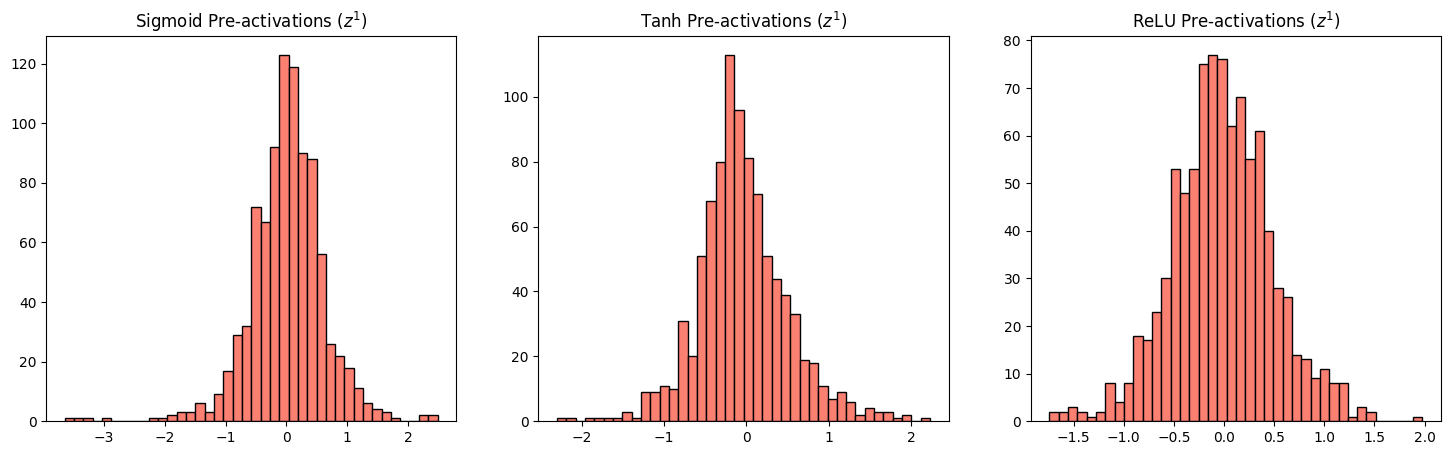

In [43]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, name in enumerate(models.keys()):
    axes[i].hist(pre_acts[name], bins=40, color='salmon', edgecolor='black')
    axes[i].set_title(f"{name} Pre-activations ($z^{(1)}$)")
plt.show()

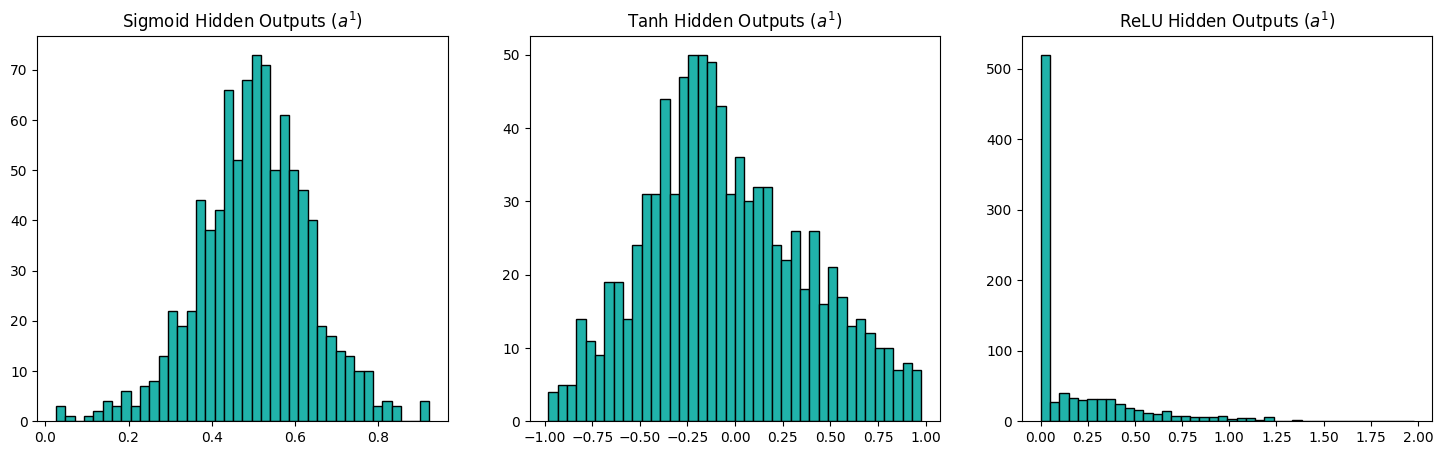

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, name in enumerate(models.keys()):
    axes[i].hist(post_acts[name], bins=40, color='lightseagreen', edgecolor='black')
    axes[i].set_title(f"{name} Hidden Outputs ($a^{(1)}$)")
plt.show()

## Activation Function Analysis

### Saturation in Sigmoid and Tanh

* **Sigmoid:** Looking at the Sigmoid Hidden Outputs, the values are concentrated between **0.2 and 0.8**. Only a very small fraction (roughly **5-10%**) falls into the saturated regions near 0 or 1, as the tails of the histogram are quite thin at the boundaries.
* **Tanh:** In the Tanh Hidden Outputs, the distribution is broader, spanning from **-1.0 to 1.0**. A slightly higher fraction, perhaps **10-15%**, appears to be approaching the saturated regions at -1 and 1 compared to the Sigmoid model.

---

### Inactive Units in ReLU

* **ReLU:** The ReLU Hidden Outputs plot shows a **massive vertical spike** at exactly 0.0.
* By comparing the height of this spike (over 500 counts) to the rest of the distribution, roughly **50-60% of the units are inactive**. This occurs because ReLU maps all negative pre-activation values from the $z^{(1)}$ distribution directly to zero.

---

### Why ReLU is the Better Default

Based on the visual evidence in the histograms, ReLU is often preferred for several reasons:

1. **No Positive Saturation:** Unlike Sigmoid and Tanh, which "squash" high values into a flat horizontal line, the ReLU histogram shows that positive values maintain their magnitude (extending up to 2.0 in this case). This prevents the **vanishing gradient problem** for positive inputs.
2. **Sparsity:** The large spike at zero indicates that the model is learning a **sparse representation**. Only a subset of neurons is active at any given time, which makes the network more computationally efficient and often leads to better generalization.
3. **Linear Behavior:** For all active units, ReLU acts as a **linear identity function**, which makes the optimization landscape much easier for gradient descent to navigate compared to the high curvature of Sigmoid or Tanh.